<a href="https://colab.research.google.com/github/SubodhWalondre-1/Machine-Vision-Lab/blob/main/prac_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload Metal Surface Image


Saving 6.jpg to 6.jpg


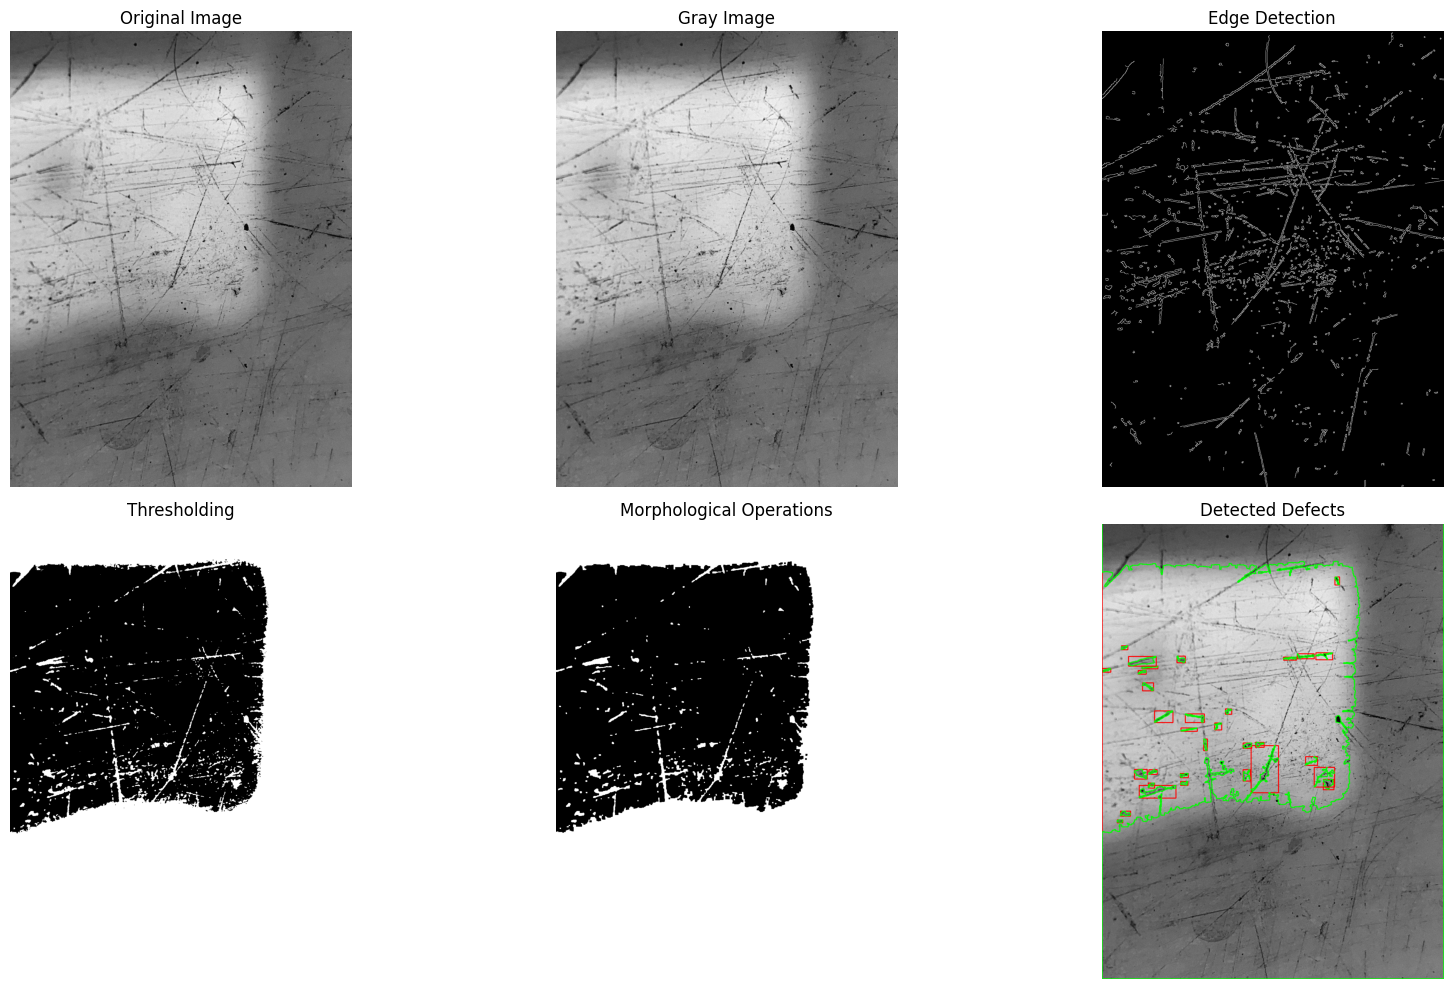

Total Defects Detected : 33


In [1]:
# ==========================================================
# DEFECT DETECTION ON METAL SURFACE
# Edge Detection + Thresholding + Segmentation
# Contours + Morphological Operations
# Google Colab
# ==========================================================

!pip -q install opencv-python-headless

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ==========================================================
# Upload Image
# ==========================================================

print("Upload Metal Surface Image")
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Read Image
img = cv2.imread(image_path)

# Convert to RGB
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ==========================================================
# Convert to Grayscale
# ==========================================================

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ==========================================================
# Gaussian Blur
# ==========================================================

blur = cv2.GaussianBlur(gray,(5,5),0)

# ==========================================================
# Edge Detection (Canny)
# ==========================================================

edges = cv2.Canny(blur,50,150)

# ==========================================================
# Thresholding
# ==========================================================

_, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# ==========================================================
# Morphological Operations
# ==========================================================

kernel = np.ones((3,3),np.uint8)

opening = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel,
    iterations=1
)

closing = cv2.morphologyEx(
    opening,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

# ==========================================================
# Find Contours
# ==========================================================

contours,_ = cv2.findContours(
    closing,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

result = rgb.copy()

count = 0

for c in contours:

    area = cv2.contourArea(c)

    if area > 100:

        x,y,w,h = cv2.boundingRect(c)

        cv2.rectangle(
            result,
            (x,y),
            (x+w,y+h),
            (255,0,0),
            2
        )

        cv2.drawContours(
            result,
            [c],
            -1,
            (0,255,0),
            2
        )

        count += 1

# ==========================================================
# Display Results
# ==========================================================

plt.figure(figsize=(18,10))

plt.subplot(2,3,1)
plt.imshow(rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(gray,cmap='gray')
plt.title("Gray Image")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(edges,cmap='gray')
plt.title("Edge Detection")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(thresh,cmap='gray')
plt.title("Thresholding")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(closing,cmap='gray')
plt.title("Morphological Operations")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(result)
plt.title("Detected Defects")
plt.axis("off")

plt.tight_layout()
plt.show()

print("=====================================")
print("Total Defects Detected :", count)
print("=====================================")